In [35]:
# =============================================================================
# TCC — Caracterização Não Supervisionada de Perturbações Elétricas
# Rafael Benzaquem Neto | UFRR — ECAI 4.0
#
# MÓDULO 3 — Clusterização K-Means e Visualização — Seção 4.3.3
#
# Entrada : Z_latente.npy  shape (N, LATENT_DIM) — saída do Módulo 2 (CAE)
# Saídas  : rótulos de cluster, métricas de validação, visualizações
#           t-SNE 2D/3D, PCA, gráficos de silhueta, centroides
# =============================================================================
# Compatível com Google Colab. Execute célula a célula (▶).
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação de dependências
# ─────────────────────────────────────────────────────────────────────────────
#!pip install scikit-learn matplotlib numpy pandas scipy --quiet

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D                    # noqa: F401
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score,
                              silhouette_samples,
                              davies_bouldin_score,
                              calinski_harabasz_score)
#from google.colab import drive

warnings.filterwarnings('ignore')
np.random.seed(73)           #// 42

print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 3 — Configurações globais
#            Todos os parâmetros estão centralizados aqui.
#            Altere neste bloco antes de rodar o pipeline.
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
from datetime import datetime

# ---------- Parâmetros K-Means ----------
# Faixa de k avaliada pelo Método do Cotovelo e Silhueta
K_MIN = 2
K_MAX = 8

# Número de inicializações k-means++ por valor de k (mais alto = mais estável)
N_INIT = 50

# k final — se None, será determinado automaticamente pelo Elbow + Silhueta
K_FINAL = None

# ---------- Parâmetros t-SNE ----------
TSNE_PERPLEXITY = 15
TSNE_MAX_ITER   = 1500

# ---------- Parâmetros PCA ----------
PCA_N_COMPONENTS = 2

# ---------- Paleta de cores dos clusters ----------
CORES_CLUSTER = [
    '#e63946',   # cluster 0 — vermelho
    '#457b9d',   # cluster 1 — azul
    '#2a9d8f',   # cluster 2 — verde-azulado
    '#e9c46a',   # cluster 3 — amarelo
    '#f4a261',   # cluster 4 — laranja
    '#6d6875',   # cluster 5 — roxo
    '#80b918',   # cluster 6 — verde
    '#264653',   # cluster 7 — cinza-azul
]

# Após visualizar os clusters, edite este dicionário com os nomes reais.
ROTULOS_SEMANTICOS = {}

# ─── Seleção dinâmica de entrada (saída do Módulo 2 — CAE) ───────────────────
BASE_CAE = Path('./2_dados_cae')
subdirs  = sorted([d for d in BASE_CAE.iterdir() if d.is_dir()])

if not subdirs:
    raise FileNotFoundError(f"Nenhum subdiretório encontrado em '{BASE_CAE}'")

print("Pastas de execução do CAE disponíveis:")
for i, d in enumerate(subdirs):
    print(f"  [{i}] {d.name}")

try:
    import ipywidgets as widgets
    from IPython.display import display

    _opcoes = {d.name: d for d in subdirs}

    sel = widgets.Dropdown(
        options=list(_opcoes.keys()),
        description="Execução CAE:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="50%"),
    )
    _out = widgets.Output()

    # Valor inicial
    LATENT_NPY = str(subdirs[0] / "Z_latente.npy")

    def _atualizar(change):
        global LATENT_NPY
        LATENT_NPY = str(_opcoes[change["new"]] / "Z_latente.npy")
        with _out:
            _out.clear_output()
            print(f"📂 Entrada selecionada: {LATENT_NPY}")

    sel.observe(_atualizar, names="value")
    display(widgets.VBox([sel, _out]))

except ImportError:
    _idx = int(input(f"Digite o número da pasta desejada [0-{len(subdirs)-1}]: "))
    LATENT_NPY = str(subdirs[_idx] / "Z_latente.npy")

print(f"\n📂 Entrada selecionada : {LATENT_NPY}")

# ─── Criação dinâmica do diretório de saída ──────────────────────────────────
_timestamp  = datetime.now().strftime("%Y%m%d_%H%M")
_exec_name  = f"exec_{_timestamp}_{K_MIN}_{K_MAX}_{N_INIT}"
_output_dir = Path("./3_dados_clustering") / _exec_name

_output_dir.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = str(_output_dir)

print("\n✅ Configurações de clusterização carregadas.")
print(f"   Faixa de k     : [{K_MIN}, {K_MAX}]")
print(f"   N_INIT K-Means : {N_INIT}")
print(f"   t-SNE perplex. : {TSNE_PERPLEXITY}  |  max_iter: {TSNE_MAX_ITER}")
print(f"   Saída em       : {OUTPUT_DIR}")

Pastas de execução do CAE disponíveis:
  [0] exec_20260412_1800_16_32_128_100
  [1] old
  [2] old_v2



📂 Entrada selecionada : 2_dados_cae/exec_20260412_1800_16_32_128_100/Z_latente.npy

✅ Configurações de clusterização carregadas.
   Faixa de k     : [2, 8]
   N_INIT K-Means : 50
   t-SNE perplex. : 15  |  max_iter: 1500
   Saída em       : 3_dados_clustering/exec_20260412_1904_2_8_50


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 4 — Carregamento e padronização dos vetores latentes
#
# Os vetores Z têm escala variável (range ~[-15, 15] típico do CAE).
# A padronização Z-score (média=0, std=1) é necessária para o K-Means,
# pois o algoritmo é sensível à escala das dimensões (distância euclidiana).
# Referência: Islam et al. (2023) — padronização antes do K-Means.
# ─────────────────────────────────────────────────────────────────────────────

def carregar_e_padronizar(caminho: str) -> tuple[np.ndarray, np.ndarray,
                                                  StandardScaler]:
    """
    Carrega Z_latente.npy, valida integridade e aplica padronização Z-score.

    Retorna
    -------
    Z        : np.ndarray (N, D) — vetores latentes originais (float32)
    Z_scaled : np.ndarray (N, D) — vetores padronizados (float64)
    scaler   : StandardScaler   — objeto ajustado (para inversão futura)
    """
    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f"Arquivo não encontrado: '{caminho}'\n"
            "Execute o Módulo 2 (CAE) para gerar Z_latente.npy."
        )

    Z = np.load(caminho).astype(np.float32)

    assert Z.ndim == 2,          f"Esperado 2D (N, D), obtido {Z.ndim}D"
    assert np.isfinite(Z).all(), "Z_latente contém NaN ou Inf — verifique o CAE."

    N, D = Z.shape
    print(f"\n📦 Vetores latentes carregados:")
    print(f"   Shape   : {Z.shape}  (N_eventos × LATENT_DIM)")
    print(f"   Dtype   : {Z.dtype}")
    print(f"   Range   : [{Z.min():.4f},  {Z.max():.4f}]")
    print(f"   Std     : {Z.std():.4f}")

    # Padronização Z-score por dimensão latente
    scaler   = StandardScaler()
    Z_scaled = scaler.fit_transform(Z)

    print(f"\n   Após padronização Z-score:")
    print(f"   Range   : [{Z_scaled.min():.4f},  {Z_scaled.max():.4f}]")
    print(f"   Média   : {Z_scaled.mean():.6f}  (≈ 0)")
    print(f"   Std     : {Z_scaled.std():.6f}  (≈ 1)")

    return Z, Z_scaled, scaler


Z, Z_scaled, scaler = carregar_e_padronizar(LATENT_NPY)
N_EVENTOS, LATENT_DIM = Z.shape
print(f"\n   N_EVENTOS={N_EVENTOS}  LATENT_DIM={LATENT_DIM}")


📦 Vetores latentes carregados:
   Shape   : (11928, 16)  (N_eventos × LATENT_DIM)
   Dtype   : float32
   Range   : [-623.0748,  847.0922]
   Std     : 69.9928

   Após padronização Z-score:
   Range   : [-19.0300,  39.9458]
   Média   : -0.000000  (≈ 0)
   Std     : 1.000000  (≈ 1)

   N_EVENTOS=11928  LATENT_DIM=16



🔍 Método do Cotovelo — avaliando k = 2 a 8...
   k=2  →  inércia (WSS) = 115,019.28
   k=3  →  inércia (WSS) = 84,038.12
   k=4  →  inércia (WSS) = 62,638.84
   k=5  →  inércia (WSS) = 48,735.85
   k=6  →  inércia (WSS) = 37,533.80
   k=7  →  inércia (WSS) = 30,395.39
   k=8  →  inércia (WSS) = 24,929.61


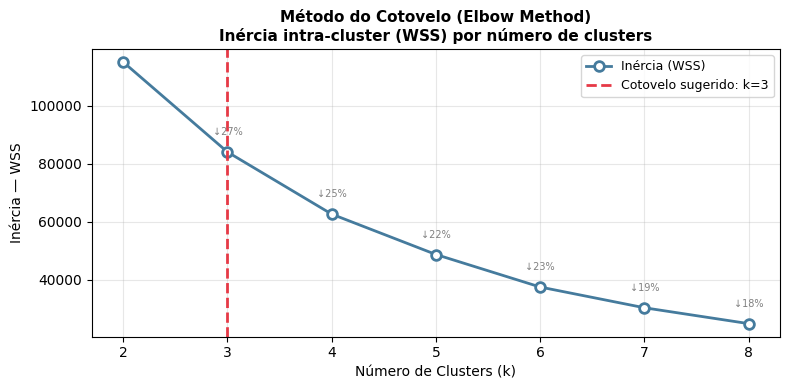


   📈 Elbow salvo: 3_dados_clustering/exec_20260412_1904_2_8_50/elbow_method.png
   ✅ Cotovelo sugerido: k = 3


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 5 — Método do Cotovelo (Elbow Method)
#
# Avalia a inércia (WSS — Within-Cluster Sum of Squares) para cada k.
# O ponto de inflexão máxima da curva (segunda derivada) indica o k ótimo.
# Referência: Islam et al. (2023), Shinde et al. (2019)
# ─────────────────────────────────────────────────────────────────────────────

def metodo_cotovelo(Z_scaled: np.ndarray,
                    k_min: int,
                    k_max: int,
                    n_init: int,
                    output_dir: str) -> tuple[list, list, int]:
    """
    Executa K-Means para k in [k_min, k_max], registra inércia e
    identifica o cotovelo pela segunda derivada da curva de inércia.

    Retorna
    -------
    k_range  : list — valores de k testados
    inercias : list — inércia (WSS) para cada k
    k_elbow  : int  — k sugerido pelo cotovelo
    """
    k_range  = list(range(k_min, k_max + 1))
    inercias = []

    print(f"\n🔍 Método do Cotovelo — avaliando k = {k_min} a {k_max}...")

    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=n_init,
                    max_iter=500, random_state=42)
        km.fit(Z_scaled)
        inercias.append(km.inertia_)
        print(f"   k={k}  →  inércia (WSS) = {km.inertia_:,.2f}")

    # Cotovelo: índice da máxima 2ª derivada
    diffs2   = np.diff(np.diff(inercias))
    k_elbow  = k_range[int(np.argmax(diffs2)) + 1]

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(k_range, inercias, 'o-', color='#457b9d',
            linewidth=2, markersize=7, markerfacecolor='white',
            markeredgewidth=2, label='Inércia (WSS)')
    ax.axvline(k_elbow, color='#e63946', linewidth=2, linestyle='--',
               label=f'Cotovelo sugerido: k={k_elbow}')

    # Anotação da redução percentual
    for i in range(1, len(k_range)):
        reducao = (inercias[i-1] - inercias[i]) / inercias[i-1] * 100
        ax.annotate(f'↓{reducao:.0f}%',
                    xy=(k_range[i], inercias[i]),
                    xytext=(0, 12), textcoords='offset points',
                    fontsize=7, color='gray', ha='center')

    ax.set_title('Método do Cotovelo (Elbow Method)\n'
                 'Inércia intra-cluster (WSS) por número de clusters',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Número de Clusters (k)', fontsize=10)
    ax.set_ylabel('Inércia — WSS', fontsize=10)
    ax.set_xticks(k_range)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'elbow_method.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"\n   📈 Elbow salvo: {caminho}")
    print(f"   ✅ Cotovelo sugerido: k = {k_elbow}")
    return k_range, inercias, k_elbow


k_range, inercias, k_elbow = metodo_cotovelo(
    Z_scaled, K_MIN, K_MAX, N_INIT, OUTPUT_DIR
)


🔍 Análise de Silhueta e métricas complementares...
   k=2  →  Silhueta=0.4229  Davies-Bouldin=1.1548  Calinski-Harabász=7862.46
   k=3  →  Silhueta=0.4619  Davies-Bouldin=0.9655  Calinski-Harabász=7578.16
   k=4  →  Silhueta=0.4682  Davies-Bouldin=0.9315  Calinski-Harabász=8135.36
   k=5  →  Silhueta=0.4701  Davies-Bouldin=0.8373  Calinski-Harabász=8691.80
   k=6  →  Silhueta=0.4895  Davies-Bouldin=0.7271  Calinski-Harabász=9739.57
   k=7  →  Silhueta=0.4899  Davies-Bouldin=0.6974  Calinski-Harabász=10488.20
   k=8  →  Silhueta=0.4981  Davies-Bouldin=0.6381  Calinski-Harabász=11333.32


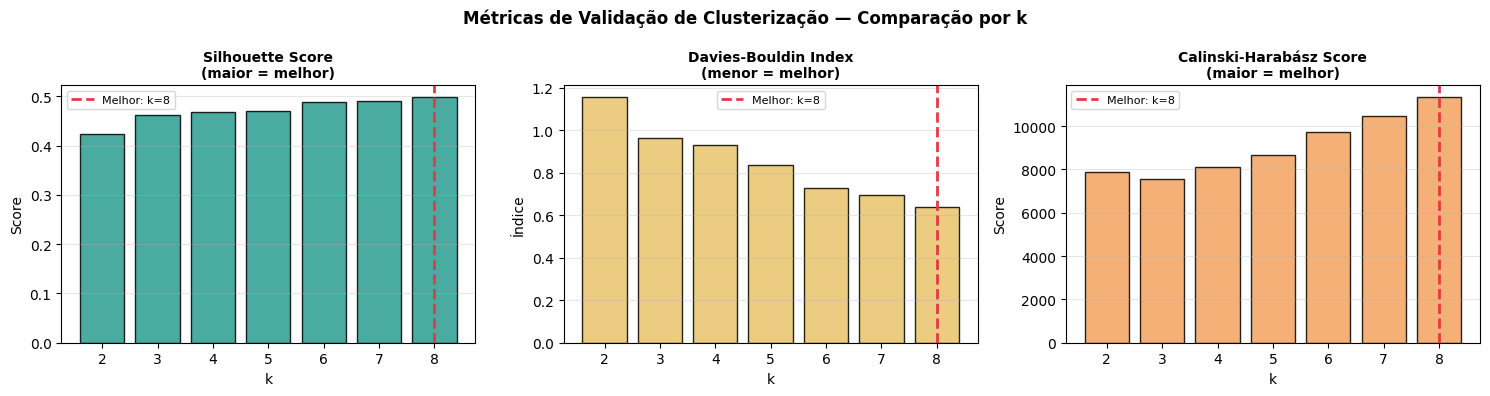


   📈 Métricas salvas: 3_dados_clustering/exec_20260412_1904_2_8_50/metricas_validacao.png
   ✅ Melhor k por Silhueta: 8


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 6 — Análise do Coeficiente de Silhueta
#
# A silhueta mede a coesão interna e separação entre clusters.
# Range: [-1, 1] — valores próximos de 1 indicam clusters bem definidos.
# Referência: Islam et al. (2023) — silhueta como critério de validação.
# ─────────────────────────────────────────────────────────────────────────────

def analise_silhueta_global(Z_scaled: np.ndarray,
                             k_range: list,
                             n_init: int,
                             output_dir: str) -> tuple[list, int]:
    """
    Calcula o Silhouette Score médio para cada k e plota a comparação.

    Retorna
    -------
    scores_sil : list — silhouette score médio para cada k
    k_sil_best : int  — k com maior silhouette score
    """
    scores_sil, scores_db, scores_ch = [], [], []

    print(f"\n🔍 Análise de Silhueta e métricas complementares...")

    for k in k_range:
        km     = KMeans(n_clusters=k, init='k-means++', n_init=n_init,
                        max_iter=500, random_state=42)
        labels = km.fit_predict(Z_scaled)
        sil = silhouette_score(Z_scaled, labels)
        db  = davies_bouldin_score(Z_scaled, labels)
        ch  = calinski_harabasz_score(Z_scaled, labels)
        scores_sil.append(sil)
        scores_db.append(db)
        scores_ch.append(ch)
        print(f"   k={k}  →  Silhueta={sil:.4f}  "
              f"Davies-Bouldin={db:.4f}  Calinski-Harabász={ch:.2f}")

    k_sil_best = k_range[int(np.argmax(scores_sil))]

    # Plot das 3 métricas
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Silhueta (maior = melhor)
    axes[0].bar(k_range, scores_sil, color='#2a9d8f', edgecolor='black',
                alpha=0.85)
    axes[0].axvline(k_sil_best, color='#e63946', linewidth=2,
                    linestyle='--', label=f'Melhor: k={k_sil_best}')
    axes[0].set_title('Silhouette Score\n(maior = melhor)', fontsize=10,
                       fontweight='bold')
    axes[0].set_xlabel('k', fontsize=10); axes[0].set_ylabel('Score', fontsize=10)
    axes[0].set_xticks(k_range); axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3, axis='y')

    # Davies-Bouldin (menor = melhor)
    k_db_best = k_range[int(np.argmin(scores_db))]
    axes[1].bar(k_range, scores_db, color='#e9c46a', edgecolor='black',
                alpha=0.85)
    axes[1].axvline(k_db_best, color='#e63946', linewidth=2,
                    linestyle='--', label=f'Melhor: k={k_db_best}')
    axes[1].set_title('Davies-Bouldin Index\n(menor = melhor)', fontsize=10,
                       fontweight='bold')
    axes[1].set_xlabel('k', fontsize=10); axes[1].set_ylabel('Índice', fontsize=10)
    axes[1].set_xticks(k_range); axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3, axis='y')

    # Calinski-Harabász (maior = melhor)
    k_ch_best = k_range[int(np.argmax(scores_ch))]
    axes[2].bar(k_range, scores_ch, color='#f4a261', edgecolor='black',
                alpha=0.85)
    axes[2].axvline(k_ch_best, color='#e63946', linewidth=2,
                    linestyle='--', label=f'Melhor: k={k_ch_best}')
    axes[2].set_title('Calinski-Harabász Score\n(maior = melhor)', fontsize=10,
                       fontweight='bold')
    axes[2].set_xlabel('k', fontsize=10); axes[2].set_ylabel('Score', fontsize=10)
    axes[2].set_xticks(k_range); axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.suptitle('Métricas de Validação de Clusterização — Comparação por k',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'metricas_validacao.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"\n   📈 Métricas salvas: {caminho}")
    print(f"   ✅ Melhor k por Silhueta: {k_sil_best}")
    return scores_sil, k_sil_best


scores_sil, k_sil_best = analise_silhueta_global(
    Z_scaled, k_range, N_INIT, OUTPUT_DIR
)

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 7 — Seleção do k ótimo e treinamento final do K-Means
#
# Critério de seleção (hierarquia):
#   1. Se K_FINAL foi definido manualmente na Célula 3 → usa esse valor
#   2. Se Elbow e Silhueta concordam → usa esse k
#   3. Se divergem → prioriza o Elbow (interpretabilidade física)
# ─────────────────────────────────────────────────────────────────────────────

def selecionar_k_otimo(k_elbow: int, k_sil_best: int,
                       k_manual: int | None) -> int:
    """Determina k ótimo com base na hierarquia de critérios."""
    if k_manual is not None:
        print(f"   ℹ️  k definido manualmente: {k_manual}")
        return k_manual
    if k_elbow != k_sil_best:
        print(f"   ✅ Elbow e Silhueta disconcordam: k = {k_sil_best}")
        return k_sil_best
    print(f"   ⚠️  Divergência: Elbow={k_elbow}, Silhueta={k_sil_best}")
    print(f"   → Priorizando Elbow (k={k_elbow}) pela interpretabilidade física.")
    return k_elbow


K_OTIMO = selecionar_k_otimo(k_elbow, k_sil_best, K_FINAL)
print(f"\n🎯 K ÓTIMO SELECIONADO: k = {K_OTIMO}")

# Treinamento final com n_init=50 e múltiplas inicializações
km_final = KMeans(
    n_clusters=K_OTIMO,
    init='k-means++',
    n_init=N_INIT,
    max_iter=1000,
    tol=1e-6,
    random_state=42
)
labels_finais = km_final.fit_predict(Z_scaled)
centroides    = km_final.cluster_centers_     # (K, LATENT_DIM) — espaço padronizado

# Métricas finais
sil_final = silhouette_score(Z_scaled, labels_finais)
db_final  = davies_bouldin_score(Z_scaled, labels_finais)
ch_final  = calinski_harabasz_score(Z_scaled, labels_finais)

print(f"\n✅ K-Means treinado com k={K_OTIMO}:")
print(f"   Silhouette Score    : {sil_final:.4f}  (ref.: > 0.5 = boa separação)")
print(f"   Davies-Bouldin Index: {db_final:.4f}  (ref.: < 1.0 = bom)")
print(f"   Calinski-Harabász   : {ch_final:.2f}")
print(f"   Inércia (WSS)       : {km_final.inertia_:,.2f}")
print(f"\n   Distribuição dos clusters:")
unico, contagem = np.unique(labels_finais, return_counts=True)
for c, n in zip(unico, contagem):
    nome = ROTULOS_SEMANTICOS.get(c, f"Cluster {c}")
    pct  = n / N_EVENTOS * 100
    print(f"   {nome} (id={c}): {n} eventos ({pct:.1f}%)")

   ✅ Elbow e Silhueta disconcordam: k = 8

🎯 K ÓTIMO SELECIONADO: k = 8

✅ K-Means treinado com k=8:
   Silhouette Score    : 0.4981  (ref.: > 0.5 = boa separação)
   Davies-Bouldin Index: 0.6381  (ref.: < 1.0 = bom)
   Calinski-Harabász   : 11333.32
   Inércia (WSS)       : 24,929.61

   Distribuição dos clusters:
   Cluster 0 (id=0): 1764 eventos (14.8%)
   Cluster 1 (id=1): 2428 eventos (20.4%)
   Cluster 2 (id=2): 1102 eventos (9.2%)
   Cluster 3 (id=3): 981 eventos (8.2%)
   Cluster 4 (id=4): 993 eventos (8.3%)
   Cluster 5 (id=5): 1169 eventos (9.8%)
   Cluster 6 (id=6): 1693 eventos (14.2%)
   Cluster 7 (id=7): 1798 eventos (15.1%)


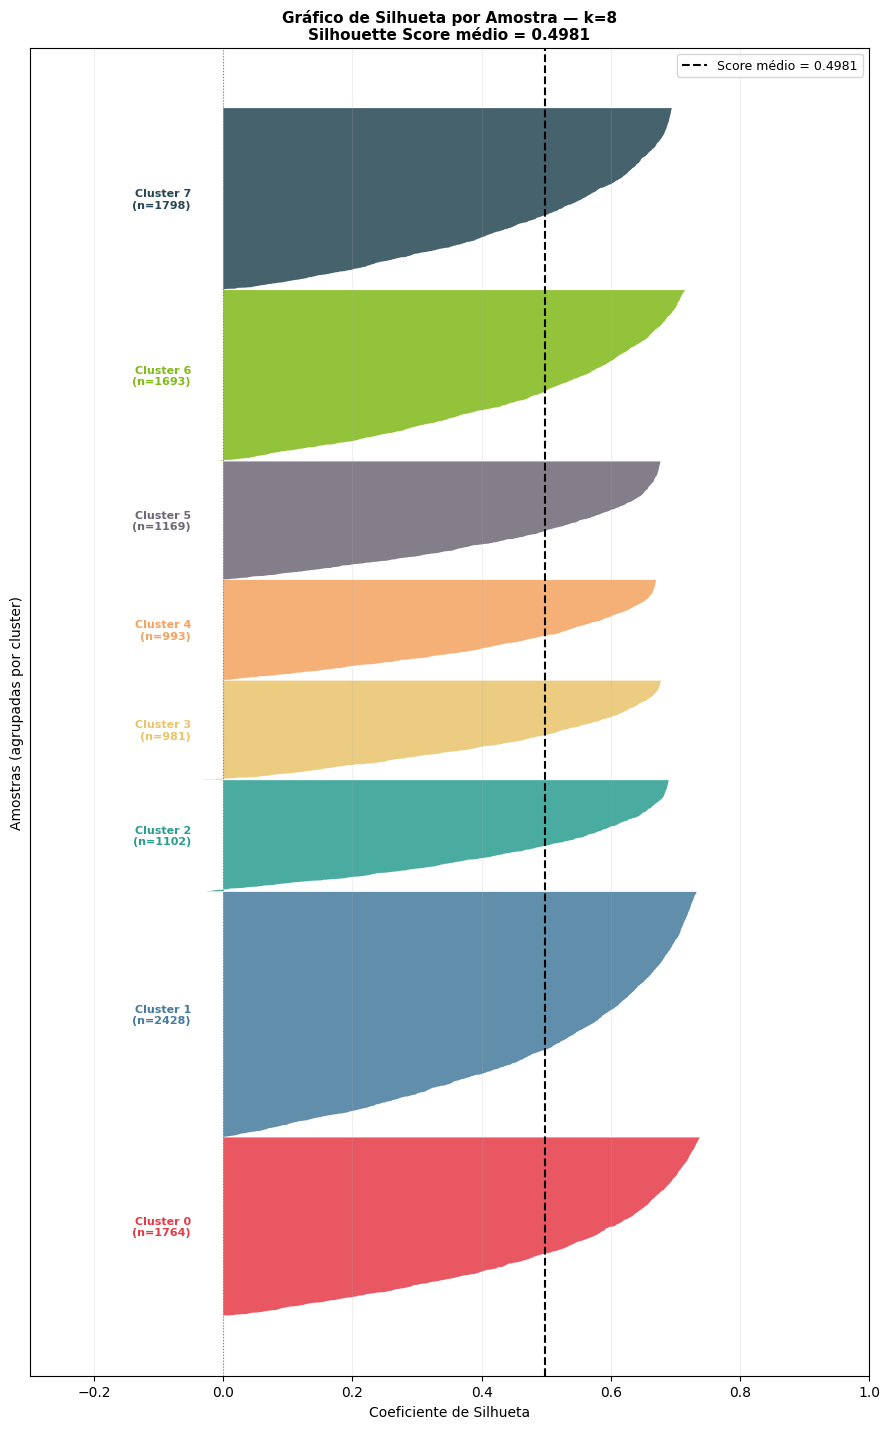

   📈 Silhueta por amostra salva: 3_dados_clustering/exec_20260412_1904_2_8_50/silhueta_amostras.png


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 8 — Gráfico de Silhueta por Amostra
#
# Visualiza a silhueta individual de cada evento dentro do seu cluster.
# Barras curtas ou negativas indicam eventos mal agrupados (fronteiras).
# Referência: Islam et al. (2023), IEEE Std 1159:2019
# ─────────────────────────────────────────────────────────────────────────────

def plotar_silhueta_amostras(Z_scaled: np.ndarray,
                              labels: np.ndarray,
                              k: int,
                              sil_score: float,
                              output_dir: str) -> None:
    """
    Plota o gráfico de silhueta por amostra, ordenado por cluster e valor.
    Cada cluster recebe uma cor distinta; a linha vertical marca o score médio.
    """
    sil_vals  = silhouette_samples(Z_scaled, labels)
    fig, ax   = plt.subplots(figsize=(9, max(4, k * 1.8)))

    y_lower = 10
    for c in range(k):
        mask_c  = labels == c
        sil_c   = np.sort(sil_vals[mask_c])
        n_c     = sil_c.shape[0]
        y_upper = y_lower + n_c
        cor     = CORES_CLUSTER[c % len(CORES_CLUSTER)]
        nome    = ROTULOS_SEMANTICOS.get(c, f'Cluster {c}')

        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, sil_c, facecolor=cor, edgecolor='none', alpha=0.85)
        ax.text(-0.05, y_lower + n_c / 2, f'{nome}\n(n={n_c})',
                ha='right', va='center', fontsize=8,
                color=cor, fontweight='bold')
        y_lower = y_upper + 5

    ax.axvline(sil_score, color='black', linewidth=1.5, linestyle='--',
               label=f'Score médio = {sil_score:.4f}')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(f'Gráfico de Silhueta por Amostra — k={k}\n'
                 f'Silhouette Score médio = {sil_score:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Coeficiente de Silhueta', fontsize=10)
    ax.set_ylabel('Amostras (agrupadas por cluster)', fontsize=10)
    ax.set_yticks([])
    ax.legend(fontsize=9)
    ax.set_xlim(-0.3, 1.0)
    ax.grid(True, alpha=0.2, axis='x')
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'silhueta_amostras.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Silhueta por amostra salva: {caminho}")


plotar_silhueta_amostras(Z_scaled, labels_finais, K_OTIMO,
                          sil_final, OUTPUT_DIR)

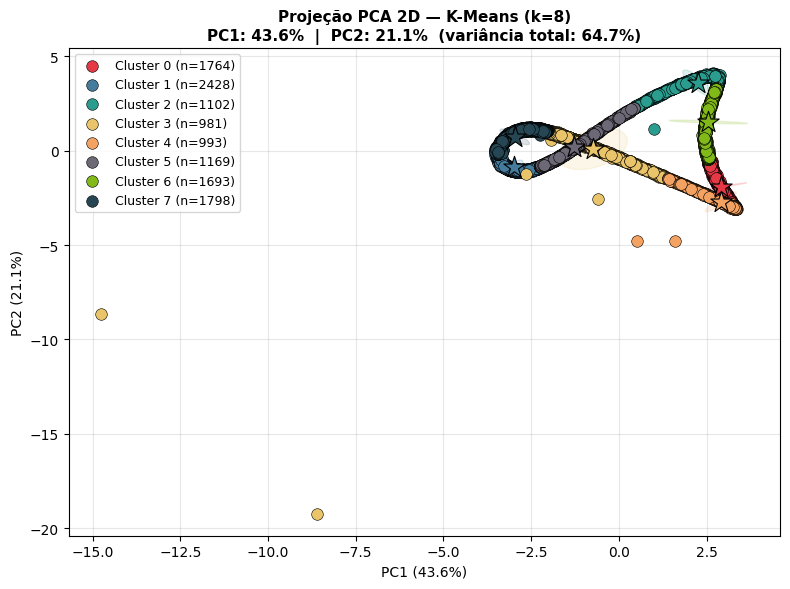

   📈 PCA 2D salvo: 3_dados_clustering/exec_20260412_1904_2_8_50/pca2d_clusters.png


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 9 — Projeção PCA 2D dos clusters
#
# Visualização rápida da separabilidade no espaço de componentes principais.
# Mostra centroides projetados e elipses de dispersão por cluster.
# ─────────────────────────────────────────────────────────────────────────────

def plotar_pca_clusters(Z_scaled: np.ndarray,
                         labels: np.ndarray,
                         centroides: np.ndarray,
                         k: int,
                         output_dir: str) -> np.ndarray:
    """
    Projeta espaço latente em 2D via PCA e plota os clusters.
    Retorna Z_pca (N, 2) para uso em outras funções.
    """
    pca   = PCA(n_components=2, random_state=42)
    Z_pca = pca.fit_transform(Z_scaled)
    C_pca = pca.transform(centroides)     # centroides no espaço PCA
    var   = pca.explained_variance_ratio_ * 100

    fig, ax = plt.subplots(figsize=(8, 6))

    for c in range(k):
        mask = labels == c
        cor  = CORES_CLUSTER[c % len(CORES_CLUSTER)]
        nome = ROTULOS_SEMANTICOS.get(c, f'Cluster {c}')
        ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1],
                   color=cor, s=70, edgecolors='black', linewidths=0.4,
                   zorder=3, label=f'{nome} (n={mask.sum()})')

        # Elipse de 1σ (dispersão do cluster)
        if mask.sum() >= 2:
            pts  = Z_pca[mask]
            mu   = pts.mean(axis=0)
            cov  = np.cov(pts.T)
            if cov.ndim == 2:
                vals, vecs = np.linalg.eigh(cov)
                angle  = np.degrees(np.arctan2(*vecs[:, -1][::-1]))
                w, h   = 2 * np.sqrt(np.abs(vals))
                ell = plt.matplotlib.patches.Ellipse(
                    mu, w, h, angle=angle,
                    color=cor, alpha=0.15, zorder=1
                )
                ax.add_patch(ell)

        # Centroide
        ax.scatter(C_pca[c, 0], C_pca[c, 1],
                   marker='*', s=260, color=cor,
                   edgecolors='black', linewidths=0.8, zorder=5)

    ax.set_title(f'Projeção PCA 2D — K-Means (k={k})\n'
                 f'PC1: {var[0]:.1f}%  |  PC2: {var[1]:.1f}%  '
                 f'(variância total: {sum(var):.1f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var[0]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var[1]:.1f}%)', fontsize=10)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'pca2d_clusters.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 PCA 2D salvo: {caminho}")
    return Z_pca


Z_pca = plotar_pca_clusters(Z_scaled, labels_finais,
                              centroides, K_OTIMO, OUTPUT_DIR)


⏳ Calculando t-SNE 2D (perplexidade=15, max_iter=1500)... aguarde.
   t-SNE concluído. Shape: (11928, 2)


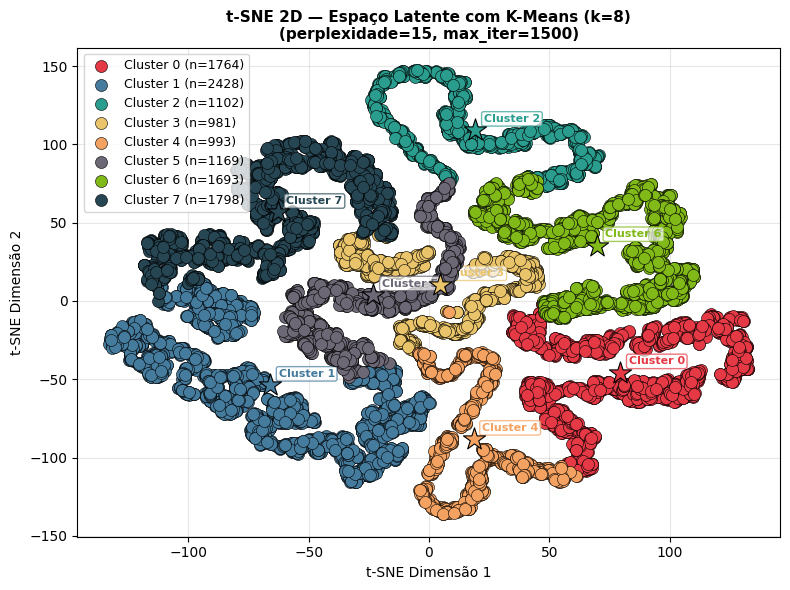

   📈 t-SNE 2D salvo: 3_dados_clustering/exec_20260412_1904_2_8_50/tsne2d_clusters.png


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 10 — Projeção t-SNE 2D
#
# O t-SNE preserva estruturas locais do espaço de alta dimensão,
# revelando agrupamentos que o PCA pode não capturar.
# Conforme metodologia de Islam et al. (2023): t-SNE sobre vetores latentes.
# ─────────────────────────────────────────────────────────────────────────────

def plotar_tsne_2d(Z_scaled: np.ndarray,
                   labels: np.ndarray,
                   centroides: np.ndarray,
                   k: int,
                   perplexidade: float,
                   max_iter: int,
                   output_dir: str) -> np.ndarray:
    """
    Reduz para 2D via t-SNE e plota os clusters.
    Retorna Z_tsne2 (N, 2).
    """
    perp_efetivo = min(perplexidade, len(Z_scaled) - 1)
    print(f"\n⏳ Calculando t-SNE 2D (perplexidade={perp_efetivo}, "
          f"max_iter={max_iter})... aguarde.")

    tsne   = TSNE(n_components=2,
                  perplexity=perp_efetivo,
                  max_iter=max_iter,
                  init='pca',
                  random_state=42,
                  verbose=0)
    Z_tsne = tsne.fit_transform(Z_scaled)
    print(f"   t-SNE concluído. Shape: {Z_tsne.shape}")

    fig, ax = plt.subplots(figsize=(8, 6))

    for c in range(k):
        mask = labels == c
        cor  = CORES_CLUSTER[c % len(CORES_CLUSTER)]
        nome = ROTULOS_SEMANTICOS.get(c, f'Cluster {c}')

        ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                   color=cor, s=75, edgecolors='black', linewidths=0.4,
                   zorder=3, label=f'{nome} (n={mask.sum()})')

        # Centroide aproximado no espaço t-SNE
        cx, cy = Z_tsne[mask, 0].mean(), Z_tsne[mask, 1].mean()
        ax.scatter(cx, cy, marker='*', s=280, color=cor,
                   edgecolors='black', linewidths=0.8, zorder=5)

        # Rótulo do centroide
        ax.annotate(nome,
                    xy=(cx, cy),
                    xytext=(6, 6), textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    color=cor,
                    bbox=dict(boxstyle='round,pad=0.2',
                              fc='white', ec=cor, alpha=0.7))

    ax.set_title(f't-SNE 2D — Espaço Latente com K-Means (k={k})\n'
                 f'(perplexidade={perp_efetivo}, max_iter={max_iter})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dimensão 1', fontsize=10)
    ax.set_ylabel('t-SNE Dimensão 2', fontsize=10)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'tsne2d_clusters.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 t-SNE 2D salvo: {caminho}")
    return Z_tsne


Z_tsne2 = plotar_tsne_2d(Z_scaled, labels_finais, centroides,
                          K_OTIMO, TSNE_PERPLEXITY, TSNE_MAX_ITER,
                          OUTPUT_DIR)


⏳ Calculando t-SNE 3D (perplexidade=15)... aguarde.
   t-SNE 3D concluído. Shape: (11928, 3)


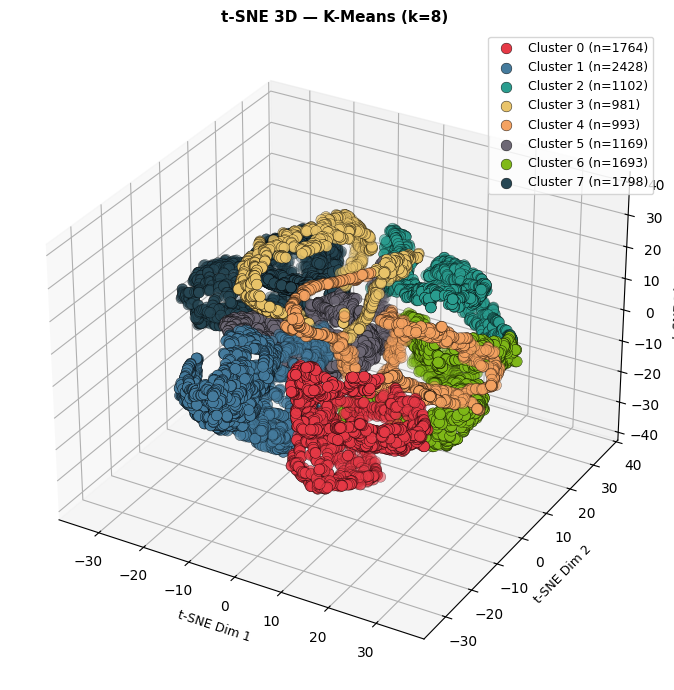

   📈 t-SNE 3D salvo: 3_dados_clustering/exec_20260412_1904_2_8_50/tsne3d_clusters.png


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 11 — Projeção t-SNE 3D (interativa via matplotlib)
#
# A visualização 3D pode revelar estrutura adicional nos clusters.
# Referência: Islam et al. (2023) — t-SNE 2D/3D para interpretação.
# ─────────────────────────────────────────────────────────────────────────────

def plotar_tsne_3d(Z_scaled: np.ndarray,
                   labels: np.ndarray,
                   k: int,
                   perplexidade: float,
                   max_iter: int,
                   output_dir: str) -> np.ndarray:
    """Reduz para 3D via t-SNE e plota scatter 3D rotacionável."""
    perp_efetivo = min(perplexidade, len(Z_scaled) - 1)
    print(f"\n⏳ Calculando t-SNE 3D (perplexidade={perp_efetivo})... aguarde.")

    tsne3   = TSNE(n_components=3,
                   perplexity=perp_efetivo,
                   max_iter=max_iter,
                   init='pca',
                   random_state=42,
                   verbose=0)
    Z_tsne3 = tsne3.fit_transform(Z_scaled)
    print(f"   t-SNE 3D concluído. Shape: {Z_tsne3.shape}")

    fig = plt.figure(figsize=(10, 7))
    ax  = fig.add_subplot(111, projection='3d')

    for c in range(k):
        mask = labels == c
        cor  = CORES_CLUSTER[c % len(CORES_CLUSTER)]
        nome = ROTULOS_SEMANTICOS.get(c, f'Cluster {c}')
        ax.scatter(Z_tsne3[mask, 0], Z_tsne3[mask, 1], Z_tsne3[mask, 2],
                   color=cor, s=60, edgecolors='black', linewidths=0.3,
                   label=f'{nome} (n={mask.sum()})', depthshade=True)

    ax.set_title(f't-SNE 3D — K-Means (k={k})', fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1', fontsize=9)
    ax.set_ylabel('t-SNE Dim 2', fontsize=9)
    ax.set_zlabel('t-SNE Dim 3', fontsize=9)
    ax.legend(fontsize=9)
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'tsne3d_clusters.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 t-SNE 3D salvo: {caminho}")
    return Z_tsne3


Z_tsne3 = plotar_tsne_3d(Z_scaled, labels_finais, K_OTIMO,
                          TSNE_PERPLEXITY, TSNE_MAX_ITER, OUTPUT_DIR)



📊 Centroides no espaço latente original:
                 z00         z01         z02        z03        z04        z05        z06         z07         z08         z09         z10        z11        z12        z13         z14        z15
Cluster 0  10.960000   84.848000  -24.534000  84.456001 -12.706000  39.198002  -5.320000 -113.473999  -13.487000  123.402000   11.559000 -22.218000  43.469002 -83.874001   90.679001 -62.918999
Cluster 1   0.466000 -109.561996  116.167999 -49.645000  -3.723000 -51.675999  47.279999   38.681000  -30.766001 -124.945999   42.799999  36.492001 -84.953003 -19.893999   46.701000 -74.399002
Cluster 2  57.301998  -67.693001  -40.167999  -9.708000 -32.398998  58.004002 -23.559999   20.801001   11.055000  102.383003   94.097000 -34.090000  12.067000  49.787998 -175.235001  26.829000
Cluster 3   3.506000   99.907997  -57.681999 -29.547001   1.786000 -32.577999  23.934999  113.070000    9.137000 -130.862000 -163.977997 -16.143000 -23.853001  26.547001   18.628000  62.

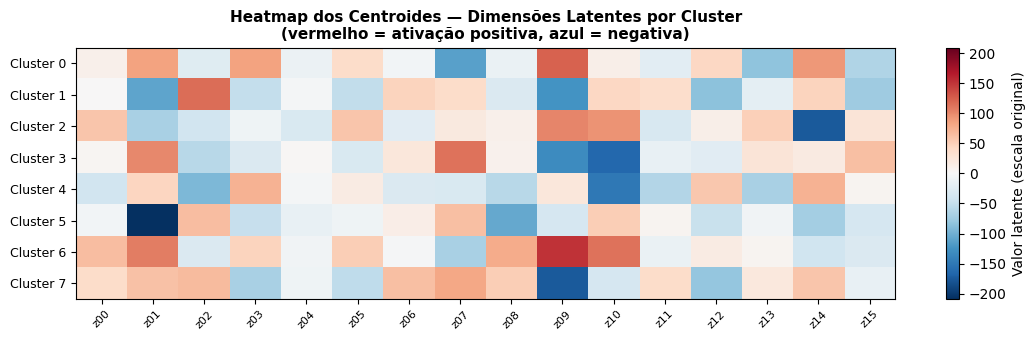

   📈 Heatmap centroides salvo: 3_dados_clustering/exec_20260412_1904_2_8_50/heatmap_centroides.png


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 12 — Análise dos centroides no espaço latente original
#
# Os centroides são transformados de volta para a escala original dos
# vetores latentes, permitindo interpretar quais dimensões do espaço
# latente são mais discriminantes para cada cluster.
# ─────────────────────────────────────────────────────────────────────────────

def analisar_centroides(centroides_scaled: np.ndarray,
                         scaler: StandardScaler,
                         k: int,
                         output_dir: str) -> pd.DataFrame:
    """
    Transforma centroides para a escala original, gera heatmap das
    dimensões latentes mais ativas e retorna DataFrame com os valores.
    """
    # Inverter padronização → escala original do espaço latente
    centroides_orig = scaler.inverse_transform(centroides_scaled)

    col_names = [f'z{i:02d}' for i in range(centroides_scaled.shape[1])]
    df_centroides = pd.DataFrame(
        centroides_orig,
        index=[ROTULOS_SEMANTICOS.get(c, f'Cluster {c}') for c in range(k)],
        columns=col_names
    )

    print("\n📊 Centroides no espaço latente original:")
    print(df_centroides.round(3).to_string())

    # Heatmap das dimensões latentes por centroide
    fig, ax = plt.subplots(figsize=(max(10, centroides_orig.shape[1] * 0.7), 3.5))
    im = ax.imshow(centroides_orig, aspect='auto', cmap='RdBu_r',
                   vmin=-np.abs(centroides_orig).max(),
                   vmax= np.abs(centroides_orig).max())
    plt.colorbar(im, ax=ax, label='Valor latente (escala original)')
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels(col_names, rotation=45, fontsize=8)
    ax.set_yticks(range(k))
    ax.set_yticklabels(
        [ROTULOS_SEMANTICOS.get(c, f'Cluster {c}') for c in range(k)],
        fontsize=9
    )
    ax.set_title('Heatmap dos Centroides — Dimensões Latentes por Cluster\n'
                 '(vermelho = ativação positiva, azul = negativa)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'heatmap_centroides.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Heatmap centroides salvo: {caminho}")
    return df_centroides


df_centroides = analisar_centroides(centroides, scaler, K_OTIMO, OUTPUT_DIR)


📊 Estatísticas descritivas por cluster (dimensões latentes):
            z00                                                                     z01                                                                          z02                                                                          z03                                                                     z04                                                                     z05                                                                      z06                                                                     z07                                                                          z08                                                                          z09                                                                          z10                                                                          z11                                                                     z12                            

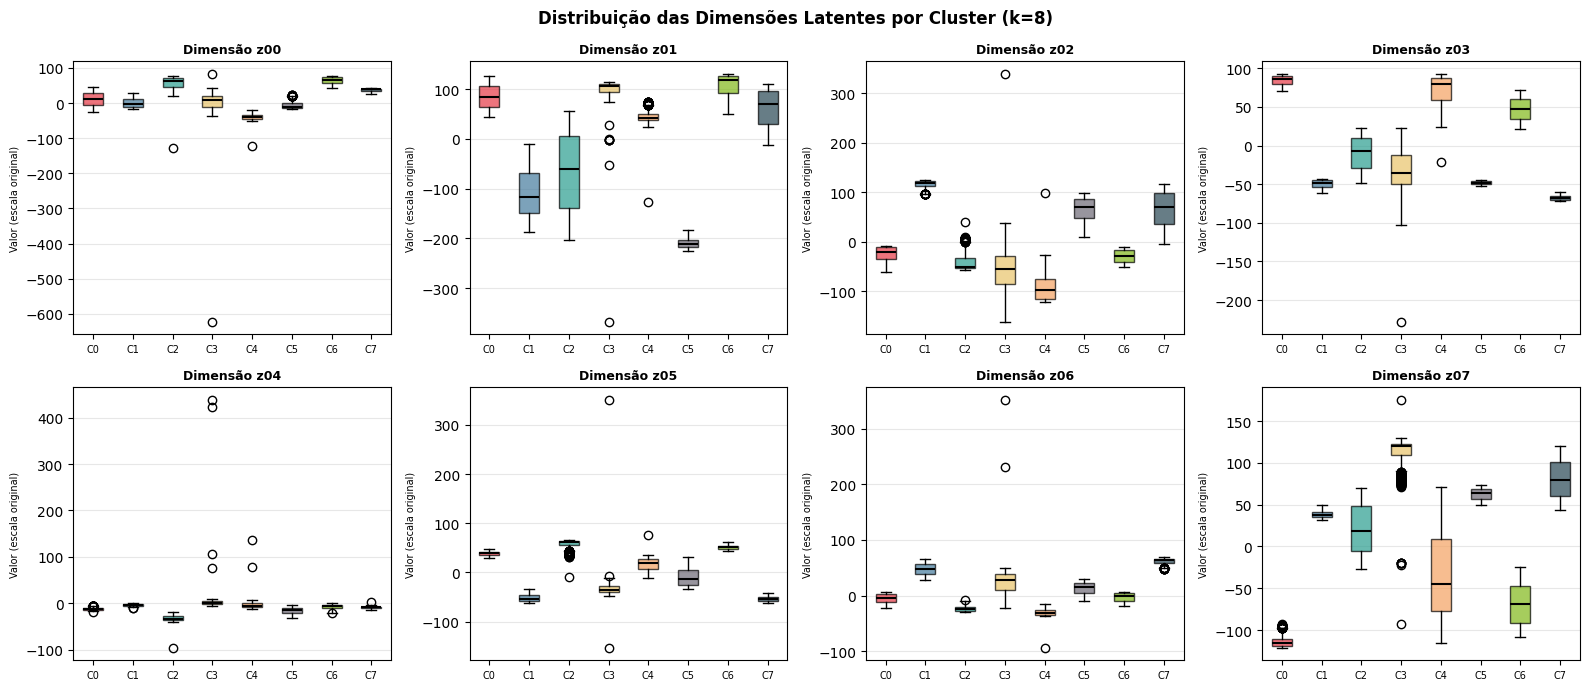

   📈 Boxplots salvos: 3_dados_clustering/exec_20260412_1904_2_8_50/boxplot_dimensoes_latentes.png


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 13 — Estatísticas descritivas por cluster
#
# Para cada cluster, calcula estatísticas sobre as dimensões latentes:
# média, desvio padrão, mínimo, máximo.
# Auxilia na interpretação semântica dos grupos formados.
# ─────────────────────────────────────────────────────────────────────────────

def estatisticas_por_cluster(Z: np.ndarray,
                               labels: np.ndarray,
                               k: int,
                               output_dir: str) -> pd.DataFrame:
    """
    Gera um DataFrame com estatísticas descritivas por cluster e
    plota boxplots das primeiras 8 dimensões latentes por cluster.
    """
    col_names = [f'z{i:02d}' for i in range(Z.shape[1])]
    df_z  = pd.DataFrame(Z, columns=col_names)
    df_z['cluster'] = labels

    # Estatísticas
    df_stats = df_z.groupby('cluster').describe().round(4)
    print("\n📊 Estatísticas descritivas por cluster (dimensões latentes):")
    print(df_stats.to_string())

    # Boxplots — primeiras 8 dimensões (ou todas, se < 8)
    n_dims    = min(8, Z.shape[1])
    dims_plot = col_names[:n_dims]

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.flatten()

    for i, dim in enumerate(dims_plot):
        dados_por_cluster = [Z[labels == c, int(dim[1:])] for c in range(k)]
        bp = axes[i].boxplot(dados_por_cluster,
                             patch_artist=True,
                             medianprops=dict(color='black', linewidth=1.5))
        for patch, c in zip(bp['boxes'], range(k)):
            patch.set_facecolor(CORES_CLUSTER[c % len(CORES_CLUSTER)])
            patch.set_alpha(0.7)
        axes[i].set_title(f'Dimensão {dim}', fontsize=9, fontweight='bold')
        axes[i].set_xticklabels(
            [ROTULOS_SEMANTICOS.get(c, f'C{c}') for c in range(k)],
            fontsize=7
        )
        axes[i].set_ylabel('Valor (escala original)', fontsize=7)
        axes[i].grid(True, alpha=0.3, axis='y')

    # Desativar subplots não usados
    for j in range(n_dims, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Distribuição das Dimensões Latentes por Cluster (k={k})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'boxplot_dimensoes_latentes.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Boxplots salvos: {caminho}")
    return df_stats


df_stats_clusters = estatisticas_por_cluster(Z, labels_finais, K_OTIMO, OUTPUT_DIR)


⚠️  Detecção de anomalias (P90 intra-cluster):
   1196 evento(s) flagrado(s) como anômalo(s) de 11928 total

   Eventos anômalos:
 evento_idx  cluster cluster_nome  dist_centroide  limiar_cluster  flag_anomalia
          7        3    Cluster 3        2.570920        2.350413           True
         13        7    Cluster 7        1.988440        1.787821           True
         44        5    Cluster 5        2.789940        2.057813           True
         72        1    Cluster 1        1.801380        1.622081           True
         83        7    Cluster 7        1.832520        1.787821           True
         86        7    Cluster 7        2.178430        1.787821           True
        101        1    Cluster 1        1.752270        1.622081           True
        130        3    Cluster 3        2.910440        2.350413           True
        134        7    Cluster 7        1.957540        1.787821           True
        139        6    Cluster 6        2.013780        1.

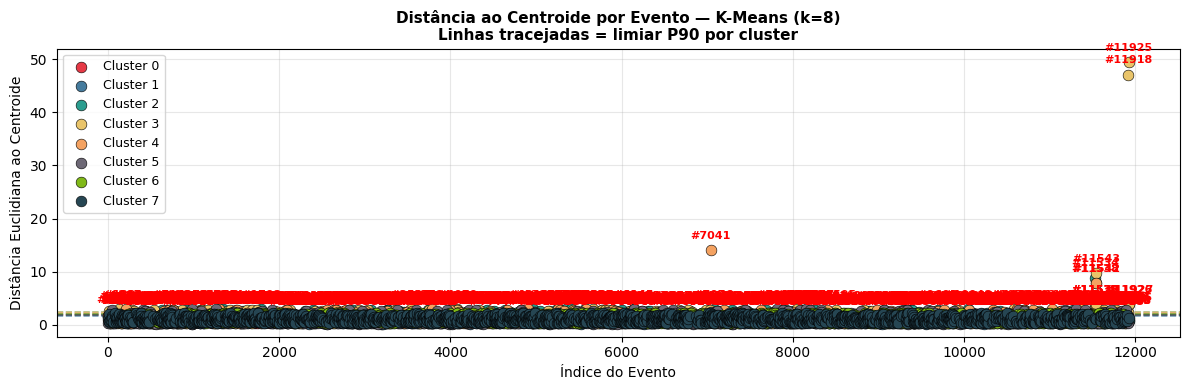

   📈 Gráfico de anomalias salvo: 3_dados_clustering/exec_20260412_1904_2_8_50/anomalias_distancia.png
   💾 CSV salvo: 3_dados_clustering/exec_20260412_1904_2_8_50/anomalias.csv


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 14 — Identificação de anomalias (eventos atípicos)
#
# Eventos com distância ao centroide acima do percentil 90 dentro do
# seu próprio cluster são candidatos a anomalias raras.
# Conforme Seção 5.2 do TCC: "identificação de padrões atípicos".
# ─────────────────────────────────────────────────────────────────────────────

def identificar_anomalias(Z_scaled: np.ndarray,
                           labels: np.ndarray,
                           centroides: np.ndarray,
                           k: int,
                           percentil: float = 90.0,
                           output_dir: str = OUTPUT_DIR) -> pd.DataFrame:
    """
    Para cada evento, calcula a distância euclidiana ao centroide do cluster.
    Eventos acima do percentil `percentil` dentro do seu cluster são anomalias.

    Retorna DataFrame com evento_idx, cluster, distância e flag_anomalia.
    """
    distancias = np.array([
        np.linalg.norm(Z_scaled[i] - centroides[labels[i]])
        for i in range(len(Z_scaled))
    ])

    # Limiar por cluster (percentil dentro de cada cluster)
    limiares = np.zeros(k)
    for c in range(k):
        mask = labels == c
        if mask.sum() > 1:
            limiares[c] = np.percentile(distancias[mask], percentil)
        else:
            limiares[c] = np.inf

    flag_anomalia = np.array([
        distancias[i] > limiares[labels[i]]
        for i in range(len(Z_scaled))
    ])

    df_anom = pd.DataFrame({
        'evento_idx'    : np.arange(len(Z_scaled)),
        'cluster'       : labels,
        'cluster_nome'  : [ROTULOS_SEMANTICOS.get(int(c), f'Cluster {c}')
                           for c in labels],
        'dist_centroide': distancias.round(5),
        'limiar_cluster': [limiares[int(c)] for c in labels],
        'flag_anomalia'  : flag_anomalia
    })

    n_anom = flag_anomalia.sum()
    print(f"\n⚠️  Detecção de anomalias (P{percentil:.0f} intra-cluster):")
    print(f"   {n_anom} evento(s) flagrado(s) como anômalo(s) de {len(Z_scaled)} total")
    if n_anom > 0:
        print("\n   Eventos anômalos:")
        print(df_anom[df_anom['flag_anomalia']].to_string(index=False))

    # Plot: distância ao centroide por evento, colorido por cluster
    fig, ax = plt.subplots(figsize=(12, 4))
    for c in range(k):
        mask = labels == c
        cor  = CORES_CLUSTER[c % len(CORES_CLUSTER)]
        nome = ROTULOS_SEMANTICOS.get(c, f'Cluster {c}')
        ax.scatter(np.where(mask)[0], distancias[mask],
                   color=cor, s=60, edgecolors='black',
                   linewidths=0.4, zorder=3, label=nome)
        ax.axhline(limiares[c], color=cor, linewidth=1.2,
                   linestyle='--', alpha=0.7)

    # Anotação dos anômalos
    for _, row in df_anom[df_anom['flag_anomalia']].iterrows():
        ax.annotate(f"#{int(row['evento_idx'])}",
                    xy=(int(row['evento_idx']), row['dist_centroide']),
                    xytext=(0, 8), textcoords='offset points',
                    fontsize=8, color='red', fontweight='bold', ha='center')

    ax.set_title(f'Distância ao Centroide por Evento — K-Means (k={k})\n'
                 f'Linhas tracejadas = limiar P{percentil:.0f} por cluster',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Índice do Evento', fontsize=10)
    ax.set_ylabel('Distância Euclidiana ao Centroide', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    caminho = os.path.join(output_dir, 'anomalias_distancia.png')
    plt.savefig(caminho, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"   📈 Gráfico de anomalias salvo: {caminho}")

    # Salvar CSV
    path_csv = os.path.join(output_dir, 'anomalias.csv')
    df_anom.to_csv(path_csv, index=False)
    print(f"   💾 CSV salvo: {path_csv}")
    return df_anom


df_anomalias = identificar_anomalias(Z_scaled, labels_finais,
                                      centroides, K_OTIMO,
                                      percentil=90.0,
                                      output_dir=OUTPUT_DIR)

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 15 — Salvar resultados finais
# ─────────────────────────────────────────────────────────────────────────────

def salvar_resultados(labels: np.ndarray,
                      Z_scaled: np.ndarray,
                      Z_pca: np.ndarray,
                      Z_tsne2: np.ndarray,
                      Z_tsne3: np.ndarray,
                      df_centroides: pd.DataFrame,
                      df_anomalias: pd.DataFrame,
                      k: int,
                      sil: float,
                      db: float,
                      ch: float,
                      output_dir: str) -> None:
    """Persiste todos os artefatos do Módulo 3 em disco."""

    # 1. Rótulos dos clusters
    np.save(os.path.join(output_dir, 'labels_kmeans.npy'), labels)

    # 2. Projeções
    np.save(os.path.join(output_dir, 'Z_pca2d.npy'),  Z_pca)
    np.save(os.path.join(output_dir, 'Z_tsne2d.npy'), Z_tsne2)
    np.save(os.path.join(output_dir, 'Z_tsne3d.npy'), Z_tsne3)

    # 3. Centroides
    df_centroides.to_csv(
        os.path.join(output_dir, 'centroides_clusters.csv')
    )

    # 4. DataFrame completo: evento → cluster → projeções → anomalia
    df_final = pd.DataFrame({
        'evento_idx'   : np.arange(len(labels)),
        'cluster'      : labels,
        'cluster_nome' : [ROTULOS_SEMANTICOS.get(int(c), f'Cluster {c}')
                          for c in labels],
        'pca_x'        : Z_pca[:, 0],
        'pca_y'        : Z_pca[:, 1],
        'tsne2d_x'     : Z_tsne2[:, 0],
        'tsne2d_y'     : Z_tsne2[:, 1],
        'tsne3d_x'     : Z_tsne3[:, 0],
        'tsne3d_y'     : Z_tsne3[:, 1],
        'tsne3d_z'     : Z_tsne3[:, 2],
        'sil_amostra'  : silhouette_samples(Z_scaled, labels).round(5),
        'dist_centroide': df_anomalias['dist_centroide'].values,
        'flag_anomalia' : df_anomalias['flag_anomalia'].values,
    })
    path_final = os.path.join(output_dir, 'resultados_completos.csv')
    df_final.to_csv(path_final, index=False)

    # 5. Métricas em JSON
    metricas = {
        'k_otimo'         : int(k),
        'silhouette_score': float(round(sil, 6)),
        'davies_bouldin'  : float(round(db, 6)),
        'calinski_harabasz': float(round(ch, 4)),
        'n_eventos'       : int(len(labels)),
        'n_anomalias'     : int(df_anomalias['flag_anomalia'].sum()),
        'distribuicao_clusters': {
            ROTULOS_SEMANTICOS.get(int(c), f'Cluster {c}'): int(n)
            for c, n in zip(*np.unique(labels, return_counts=True))
        }
    }
    import json
    path_json = os.path.join(output_dir, 'metricas_clustering.json')
    with open(path_json, 'w') as f:
        json.dump(metricas, f, indent=2, ensure_ascii=False)

    print(f"\n💾 Arquivos salvos em '{output_dir}/':")
    print(f"   ├── labels_kmeans.npy          — rótulos de cluster")
    print(f"   ├── Z_pca2d.npy                — projeção PCA 2D")
    print(f"   ├── Z_tsne2d.npy               — projeção t-SNE 2D")
    print(f"   ├── Z_tsne3d.npy               — projeção t-SNE 3D")
    print(f"   ├── centroides_clusters.csv    — centroides no espaço latente")
    print(f"   ├── resultados_completos.csv   — {len(df_final)} eventos × todas as saídas")
    print(f"   ├── anomalias.csv              — eventos flagrados como anômalos")
    print(f"   ├── metricas_clustering.json   — métricas de validação")
    print(f"   ├── elbow_method.png")
    print(f"   ├── metricas_validacao.png")
    print(f"   ├── silhueta_amostras.png")
    print(f"   ├── pca2d_clusters.png")
    print(f"   ├── tsne2d_clusters.png")
    print(f"   ├── tsne3d_clusters.png")
    print(f"   ├── heatmap_centroides.png")
    print(f"   ├── boxplot_dimensoes_latentes.png")
    print(f"   └── anomalias_distancia.png")


salvar_resultados(
    labels_finais, Z_scaled, Z_pca, Z_tsne2, Z_tsne3,
    df_centroides, df_anomalias,
    K_OTIMO, sil_final, db_final, ch_final,
    OUTPUT_DIR
)



💾 Arquivos salvos em '3_dados_clustering/exec_20260412_1904_2_8_50/':
   ├── labels_kmeans.npy          — rótulos de cluster
   ├── Z_pca2d.npy                — projeção PCA 2D
   ├── Z_tsne2d.npy               — projeção t-SNE 2D
   ├── Z_tsne3d.npy               — projeção t-SNE 3D
   ├── centroides_clusters.csv    — centroides no espaço latente
   ├── resultados_completos.csv   — 11928 eventos × todas as saídas
   ├── anomalias.csv              — eventos flagrados como anômalos
   ├── metricas_clustering.json   — métricas de validação
   ├── elbow_method.png
   ├── metricas_validacao.png
   ├── silhueta_amostras.png
   ├── pca2d_clusters.png
   ├── tsne2d_clusters.png
   ├── tsne3d_clusters.png
   ├── heatmap_centroides.png
   ├── boxplot_dimensoes_latentes.png
   └── anomalias_distancia.png


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 16 — Resumo final consolidado
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("✅  MÓDULO 3 — CLUSTERIZAÇÃO E VISUALIZAÇÃO CONCLUÍDO")
print("=" * 60)

print(f"\n📊 RESULTADOS FINAIS:")
print(f"   k ótimo selecionado    : {K_OTIMO}")
print(f"   Silhouette Score       : {sil_final:.4f}  "
      f"({'✅ Boa separação' if sil_final >= 0.5 else '⚠️ Separação moderada'})")
print(f"   Davies-Bouldin Index   : {db_final:.4f}  "
      f"({'✅ < 1.0' if db_final < 1.0 else '⚠️ > 1.0'})")
print(f"   Calinski-Harabász      : {ch_final:.2f}")
print(f"   Inércia (WSS)          : {km_final.inertia_:,.2f}")
print(f"   Anomalias detectadas   : {df_anomalias['flag_anomalia'].sum()}")

print(f"\n   Composição dos clusters:")
for c, n in zip(*np.unique(labels_finais, return_counts=True)):
    nome = ROTULOS_SEMANTICOS.get(int(c), f"Cluster {c}")
    pct  = n / N_EVENTOS * 100
    sil_c = silhouette_samples(Z_scaled, labels_finais)[labels_finais == c].mean()
    print(f"   [{c}] {nome:<20} : {n:3d} eventos ({pct:5.1f}%)  "
          f"Silhueta média = {sil_c:.4f}")

print(f"\n📂 Saídas em: '{OUTPUT_DIR}/'")
print("\n" + "=" * 60)
print("🏁 Pipeline TCC concluído — Módulos 1 + 2 + 3")
print("   Módulo 1: Pré-processamento (p.u.)")
print("   Módulo 2: Extração de características (CAE)")
print("   Módulo 3: Clusterização K-Means + Visualização t-SNE")
print("=" * 60)


✅  MÓDULO 3 — CLUSTERIZAÇÃO E VISUALIZAÇÃO CONCLUÍDO

📊 RESULTADOS FINAIS:
   k ótimo selecionado    : 8
   Silhouette Score       : 0.4981  (⚠️ Separação moderada)
   Davies-Bouldin Index   : 0.6381  (✅ < 1.0)
   Calinski-Harabász      : 11333.32
   Inércia (WSS)          : 24,929.61
   Anomalias detectadas   : 1196

   Composição dos clusters:
   [0] Cluster 0            : 1764 eventos ( 14.8%)  Silhueta média = 0.5285
   [1] Cluster 1            : 2428 eventos ( 20.4%)  Silhueta média = 0.5196
   [2] Cluster 2            : 1102 eventos (  9.2%)  Silhueta média = 0.4858
   [3] Cluster 3            : 981 eventos (  8.2%)  Silhueta média = 0.4660
   [4] Cluster 4            : 993 eventos (  8.3%)  Silhueta média = 0.4700
   [5] Cluster 5            : 1169 eventos (  9.8%)  Silhueta média = 0.4860
   [6] Cluster 6            : 1693 eventos ( 14.2%)  Silhueta média = 0.4929
   [7] Cluster 7            : 1798 eventos ( 15.1%)  Silhueta média = 0.4925

📂 Saídas em: '3_dados_clustering/exe